# Preservation across areas and species
Morphoelectric properties of inhibitory neurons shift gradually with cortical depth across areas and species.

In [1]:
# Load project-specific library
import decoupling

# Load other required libraries
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# Define global matplotlib settings
plt.rcParams.update({
    "font.family": "Arial",
})

# Set random seed
seed = decoupling.set_seed(0)

# Set path to data
data_path = "../data/"

Random seed 0 has been set.


In [2]:
# Read mouse v1 EM metadata
v1_em_metadata = pd.read_csv(
    os.path.join(data_path, "mouse_v1/v1_em_metadata.csv"), 
    index_col="neuron_id",
)

# Read mouse v1 EM features
v1_em_features = pd.read_csv(
    os.path.join(data_path, "mouse_v1/processed/v1_em_features.csv"), 
    index_col="neuron_id",
)

In [3]:
# Select features to include in patchseq analyses
features_list = [
    "dendrite_vertical_extent", 
    "axon_vertical_extent", 
    "spike_frequency",
]

# Prepare patch-seq datasets
all_dfs = []
for ds in json.load(open(os.path.join(data_path,"dataset_config.json"))):

    # Read metadata
    metadata = pd.read_csv(
        os.path.join(data_path, ds["metadata_path"]), 
        index_col="neuron_id",
    )

    # Drop neurons with missing depth
    metadata = metadata[metadata["normalized_soma_depth"].notna()]  
    
    # Map molecular identities 
    # If t_cluster, extract first word (RNA family)
    metadata["molecular_identity"] = (
        metadata[ds["molecular_col"]]
        .astype(str)
        .str.split().str[0]   
        .replace(ds["molecular_map"])
        .fillna("unknown")
    )
    
    # Add species and area column
    metadata["species_area"] = ds["species_area"]

    # Keep only required metadata columns
    metadata = metadata[
        ["species_area", "molecular_identity", "normalized_soma_depth"]]
    
    # Read features
    features = pd.read_csv(
        os.path.join(data_path, ds["features_path"]), 
        index_col="neuron_id",       
    )[features_list]
    
    # Merge metadata and features
    df = metadata.merge(features, left_index=True, right_index=True, how="inner")
    all_dfs.append(df)

# Concatenate all datasets
cross_species = pd.concat(all_dfs, axis=0, ignore_index=True)

## Depth-dependent gradients in a dense electron-microscopic (EM) reconstruction
* Analysis of mouse V1 EM-reconstructed inhibitory neurons within the same animal.
* Distributions of dendritic and axonal extents of inhibitory neurons shift gradually along cortical depth.

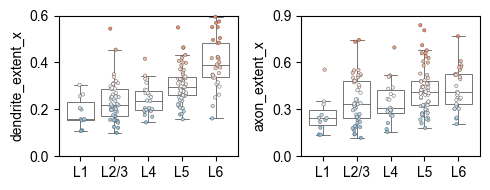

In [4]:
# Add layer labels to features
X = (
    v1_em_features.copy()
    .assign(layer=v1_em_metadata["layer"])  
    .sort_values(by="layer")
)

# Set dendrite and axon ticks in mm
ticks = [[0, 0.2, 0.4, 0.6], \
         [0, 0.3, 0.6, 0.9]]

# Plot morphological features by cortical layer
fig, axs = decoupling.plot_features_by_layer(
    X=X, ticks=ticks, figsize=(5,2),
)
plt.show()

## Comparison of of depth-dependent gradients
* Analysis of inhibitory neurons in rat vS1, mouse V1 and M1, and human MTG.
* Morphoelectric properties shift similarly with cortical depth across areas and species.

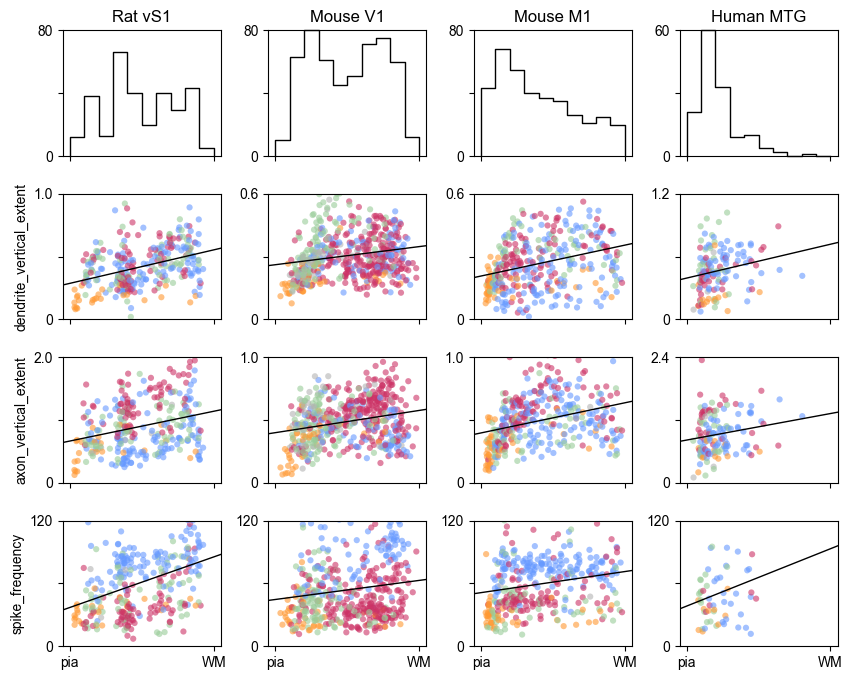

In [5]:
# Colors
pv_axon  = np.array([[102,153,255]])/255    # 6699FF
nvp_axon = np.array([[255,153,51]])/255     # FF9933
vip_axon = np.array([[153,204,153]])/255    # 99CC99
sst_axon = np.array([[204,51,102]])/255     # CC3366

palette = {'Lamp5': nvp_axon, 'PV': pv_axon, 
           'Sst': sst_axon, 'Vip': vip_axon, 
           'unknown': np.array([[0.7,0.7,0.7]])}

species_list = ["Rat vS1", "Mouse V1", "Mouse M1", "Human MTG"]
nmax_list  = [80, 80, 80, 60]
dend_list  = [1.0, 0.6, 0.6, 1.2]
axon_list  = [2.0, 1.0, 1.0, 2.4]

features_list = ["dendrite_vertical_extent", "axon_vertical_extent", "spike_frequency"]

# Create a 4x4 figure
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(10, 8), sharex=True)
fig.subplots_adjust(hspace=0.3, wspace=0.3)

for col_idx, (ds, nmax, dend, axon) in enumerate(zip(species_list, nmax_list, dend_list, axon_list)):
    X = cross_species[cross_species["species_area"]==ds]
    all_ticks  = [[0, nmax/2, nmax], [0, dend/2, dend], [0, axon/2, axon], [0, 60, 120]]
    
    for row_idx, (i, tk) in enumerate(zip(["normalized_soma_depth"] + features_list, all_ticks)):
        ax = axs[row_idx, col_idx]
        
        if i == 'normalized_soma_depth':
            hist_counts, bin_edges = np.histogram(X[i], bins=np.linspace(0, 1, 1 + 10))
            ax.step(np.concatenate([bin_edges, [1]]), np.concatenate([[0], hist_counts, [0]]), 
                    where='pre', color='black', linewidth=1.0, clip_on=False)
        else:
            X_now = X[['normalized_soma_depth', i, 'molecular_identity']].dropna()
            kwargs = {'s':20, 'marker':'o', 'alpha':0.6, 'legend':False, 'linewidth':0, 'clip_on':True}
            sns.scatterplot(data=X_now, x='normalized_soma_depth', y=i, 
                            hue='molecular_identity', palette=palette, ax=ax, **kwargs)
            sns.regplot(data=X_now, x='normalized_soma_depth', y=i, scatter=False, ci=None, 
                        color='black', truncate=False, line_kws={"linewidth":1.0}, ax=ax)
        
        ax.set_ylim([tk[0], tk[-1]])
        ax.set_yticks(tk)
        ax.set_yticklabels([f'{tk[0]}', '', f'{tk[-1]}'])

        if col_idx != 0:
            ax.set_ylabel("")
        
        if row_idx == 3:
            ax.set_xticks([0, 1])
            ax.set_xticklabels(['pia', 'WM'])
        else:
            ax.set_xticklabels([])
        
        ax.set_xlabel("")
        ax.legend([], [], frameon=False)

# add column titles for species
for col_idx, ds in enumerate(species_list):
    axs[0, col_idx].set_title(ds)

plt.show()

## Depth-independent variations
* Morphoelectric properties are z-scored across all cortical depths.
* Variations of these properties separate equally well between molecular types. 

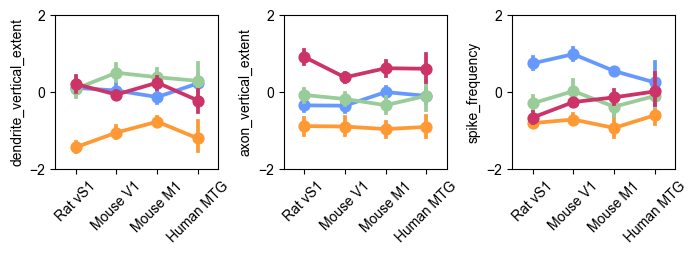

In [6]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8,2), sharex=True)
fig.subplots_adjust(wspace=0.4)

for (i, ax) in zip(features_list, axs):

    # Select current feature and remove invalid neurons
    X = cross_species[[i, "species_area", "molecular_identity"]]
    X = X[X["molecular_identity"] != "unknown"].dropna()

    # Z-score within each species and area
    X[i] = X.groupby("species_area")[i].transform(zscore)
    

    # Plot features by species and area
    sns.pointplot(
        data=X, 
        x="species_area", 
        y=i, 
        hue="molecular_identity", 
        palette=palette, 
        ax=ax,
    )

    # Axis annotations and formatting
    ax.tick_params(axis='x', rotation=45) 
    ax.legend([],[],frameon=False)
    ax.set_yticks([-2,0,2])
    ax.set_ylim([-2, 2])
    ax.set_xlabel("")
    
plt.show()